Pontifícia Universidade Católica do Rio Grande do Sul – PUCRS Escola Politécnica

Disciplina: Introdução à Visão Computacional

Profª. Daniela Oliveira Ferreira do Amaral

Nome: Lucas Leuck de Oliveira


O objetivo dessa atividade é a compreensão inicial sobre o reconhecimento de faces,  uma das principais tarefas de visão computacional, bem como a apresentação de uma de suas aplicações.

Fontes:

Paper - A survey on computer vision based human analysis in the COVID-19 era

Nesse contexto, responda as seguintes questões:

- 1) Como o uso de máscaras faciais afetou as tecnologias de visão computacional?

> As tecnologias de visão computacional utilizavam para muitas áreas principalmente de segurança o reconhecimento facil das pessoas utilizando o rosto por inteiro da pessoa, usando cada detalhe para diferenciar uma das outras. Porém com a entrada do uso de máscaras, boa parte dessa informação sumiu da imagem e o que ficou no lugar passou a agir como ruído estruturado: a máscara cobre sempre a mesma região e traz padrões próprios (cor, textura, dobras, estampas) que não têm relação nenhuma com a identidade. O modelo perde sinal útil e ainda ganha informação irrelevante, então duas pessoas diferentes com máscaras parecidas ficam mais parecidas entre si para o sistema, enquanto a mesma pessoa com e sem máscara fica menos parecida consigo mesma.

- 2) Quais as técnicas desenvolvidas nessa pesquisa, para enfrentar esses desafios, incluindo métodos de detecção e reconhecimento de rostos com máscara?

>  Basicamente as técnicas foram divididas em duas frentes principais:

> - Detectar se o rosto tinha máscara
> - Reconhecimento facial com máscara

> Na parte de detecção **(Seç. 3.1, p. 3–5)**, a estratégia foi adaptar detectores de objeto que já existiam: os trabalhos pré-pandemia usavam Viola-Jones e, mais recentemente, passaram a adotar MTCNN, RetinaFace, SSD, Faster R-CNN e variações do YOLO (v2, v3 e v5) **(p. 4)**.
>
>O padrão mais comum é um pipeline em duas etapas, no qual um primeiro detector localiza o rosto e, em seguida, uma CNN classificadora (como Inception-v3, MobileNetV2 ou EfficientNet) determina a categoria. Entre as abordagens, usaram:
>
> - SSDMNV2: combina SSD com MobileNetV2, resultando em um modelo leve o bastante para rodar direto no celular;
>
> - SE-YOLOv3: usa blocos Squeeze-and-Excitation e focal loss para concentrar o aprendizado nos detalhes mais relevantes;
>
> - SRCNet: aplica super-resolução antes de classificar quando a imagem da face tem menos de 150×150 px **(p. 4)**.
>
>Uma mudança importante foi que o problema deixou de ser uma checagem de "tem rosto ou não" e passou a trabalhar com três classes: sem máscara, com máscara e máscara mal colocada **(p. 4, Fig. 3)**. Para suprir a falta de dados na época, os pesquisadores criaram novos datasets (como MAFA, WMD, Moxa3K e BAFMD) além de bases sintéticas, inserindo máscaras digitalmente sobre fotos comuns.

> Para o reconhecimento facial com máscara, o artigo organiza tudo em quatro estratégias **(Seç. 3.2.2, p. 5–6, Fig. 4)**:
>
> - 1.In-painting **(p. 5)**: o sistema "apaga" a máscara e reconstrói a parte escondida do rosto antes de reconhecer. Funciona, mas é caro de treinar e pode gerar artefatos.
>
> - 2.Template unmasking **(p. 5–6)**: não mexe na imagem, mexe no vetor de características: transforma o template do rosto mascarado pra ele se comportar como se fosse de um rosto sem máscara.
>
> - 3.Otimização do modelo **(p. 6)**: treinar a rede de reconhecimento já com rostos mascarados, usando funções de perda adaptadas (ArcFace multitarefa, triplet loss, margens maiores) e destilação de conhecimento.
>
> - 4.Reconhecimento periocular **(p. 6)**: desistir da parte de baixo do rosto e reconhecer só pela região dos olhos e sobrancelhas.

- 3) Descreva o data set utilizado nos experimentos desse artigo.

> O artigo analisa cerca de 25 datasets **(Seç. 4, p. 11–15)** com um resumo geral na Tabela 2 **(p. 13)**, divididas principalmente entre máscaras reais (fotos autênticas) e artificiais (máscaras aplicadas digitalmente), além de categorizadas pelo foco (detecção ou reconhecimento).
>
> As bases são comparadas por critérios como o volume de imagens, a diversidade dos sujeitos, as variações de pose, o tipo de anotação (como bounding boxes, ID do indivíduo e categoria da máscara), a finalidade (detecção ou reconhecimento) e se as máscaras são reais ou sintéticas.
>
>Bases de Detecção (Máscaras Reais) **(p. 11)**
>
> - MAFA: Pioneira (2017), possui 30.811 imagens (35.806 rostos) com anotações de pose e oclusão. Limitação: predominância asiática e muitos usos incorretos da máscara.
>
> - ISL-UFMD / ISL-UFHD: Criadas pelos autores reúne 20.891 imagens no total (11.075 sem máscara, 9.300 com uso correto e 513 com uso incorreto), focadas em diversidade étnica, etária e de gênero. Inclui variação de uso correto, incorreto e interações mão e rosto.
>
> - BAFMD: 6.264 imagens (mais de 16 mil anotações) coletadas do Twitter para reduzir vieses de gênero e etnia.
>
> - Outras: FaceMask, FMLD, PWMFD, MMD, AIZOO e bases do Kaggle.
>
>
> Bases Sintéticas (Máscaras Simuladas) **(p. 12 e p. 14)**
>
>- MaskedFace-Net: 137.016 imagens derivadas da FFHQ, divididas entre uso correto(CMFD) e incorreto (IMFD).
>
>- SMFRD: 500.000 imagens cobrindo 10.000 indivíduos.
>
>- MS1MV2-Masked: Versão adaptada em larga escala do MS1MV2 (que originalmente soma 5,8 milhões de imagens e 85 mil identidades), aparecendo na Tabela 2 com 57,5 milhões de imagens para o treinamento de modelos de reconhecimento



- 4) Como o modelo de CNN contribuiu positivamente, durante a pandemia do COVID-19?

> Durante a pandemia, as CNNs se tornaram a base de praticamente todas as soluções de visão computacional. Na detecção de máscaras **(Seç. 3.1, p. 3–5)**, a combinação de redes como Inception-v3, MobileNetV2 e EfficientNet com detectores do tipo SSD, YOLO e RetinaFace permitiu automatizar a fiscalização do uso de máscaras em locais públicos, checando não só a presença da máscara, mas se o uso estava correto. Já no reconhecimento facial, o ajuste das funções de perda e o treino com rostos cobertos **(Seç. 3.2.2, p. 5–6)** permitiram recuperar a precisão dos sistemas, garantindo o funcionamento do controle de acesso sem contato.
>
> O uso das CNNs também se estendeu a outras ações de prevenção:
>
> Distanciamento e aglomerações: Métodos de detecção e regressão com CNN ajudaram a estimar o fluxo de pessoas e o espaço entre elas  **(Seç. 3.6, p. 8–9, Tabela 1)**.
>
> Sintomas e hábitos: As redes foram aplicadas na medição da frequência respiratória **(Seç. 3.7, p. 10)** e na identificação do toque da mão no rosto, onde superaram abordagens tradicionais, atingindo 93,35% de acurácia com a EfficientNet-b2 **(Seç. 3.8, p. 10)**.
>
> Geração de dados: Modelos generativos baseados em CNN foram usados para remover máscaras virtualmente e criar dados sintéticos **(Seç. 3.9, p. 10–11)**, compensando a escassez de imagens no início da crise.

- 5) Pesquise e envie uma implementação (notebook) que descreva esse pipeline.

> O pipeline tem cinco passos. Primeiro o detector localiza a face na foto. Depois a CNN transforma essa face em um embedding, um vetor de 128 números que funciona como a digital do rosto. Esse vetor é guardado em um banco vetorial junto com o nome da pessoa. Quando chega uma imagem nova, o sistema gera o embedding dela e faz uma busca por similaridade no banco, usando similaridade de cosseno ou distância euclidiana, e retorna o cadastro mais próximo.
>
>O que a CNN faz de mais importante é aproximar os vetores de fotos da mesma pessoa e afastar os de pessoas diferentes. Com isso o reconhecimento vira uma busca por vizinho mais próximo, que continua rápida mesmo com milhares de rostos cadastrados.
>
> Fonte: SIFAT. How to Perform Face Recognition on a Large Collection of Faces with Python. Medium. Disponível em: https://medium.com/@sifat777/how-to-perform-face-recognition-on-a-large-collection-of-faces-with-python-884b59a5a3dd








In [ ]:
!pip install face_recognition chromadb -q

pessoa1.jpg


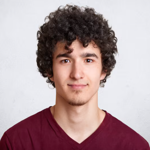

pessoa2.jpg


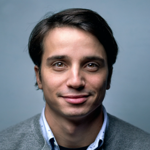

desconhecido.jpg


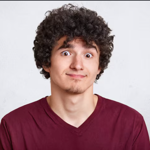

In [ ]:
!pip install gdown -q

!gdown -q "19ga4cYb_cOY0LftzQGLPcpGwVa5-tvy9" -O pessoa1.jpg
!gdown -q "1cyoESTKP8Y_Ftn0vWGjGXGTuBGzP55v2" -O pessoa2.jpg
!gdown -q "1lCQ19AEyTgAmX7V2IanqTbpFgYH1eVHY" -O desconhecido.jpg

# conferindo se baixou certo
from IPython.display import display
from PIL import Image
for f in ["pessoa1.jpg", "pessoa2.jpg", "desconhecido.jpg"]:
    print(f)
    display(Image.open(f).resize((150, 150)))

In [ ]:
import face_recognition

img = face_recognition.load_image_file("pessoa1.jpg")

# 1) deteccao: localiza as faces na imagem
boxes = face_recognition.face_locations(img, model="hog")
print("faces encontradas:", len(boxes))

# 2) embedding: a CNN converte cada face em um vetor de 128 dimensoes
embeddings = face_recognition.face_encodings(img, boxes)
emb1 = embeddings[0]
print("tamanho do embedding:", len(emb1))

faces encontradas: 1
tamanho do embedding: 128


In [ ]:
from numpy import dot
from numpy.linalg import norm

def cosine_similarity(a, b):
    return dot(a, b) / (norm(a) * norm(b))

img2 = face_recognition.load_image_file("pessoa2.jpg")
emb2 = face_recognition.face_encodings(img2)[0]

sim = cosine_similarity(emb1, emb2)
print("similaridade:", sim)
print("mesma pessoa?", sim > 0.92)   # limiar ajustavel

# metrica oficial da biblioteca: distancia euclidiana (< 0.6 = mesma pessoa)
dist = face_recognition.face_distance([emb1], emb2)[0]
print("distancia:", dist)
print("mesma pessoa (metrica oficial)?", dist < 0.6)

similaridade: 0.8718330382335682
mesma pessoa? False
distancia: 0.7382196847737891
mesma pessoa (metrica oficial)? False


In [ ]:
import chromadb

client = chromadb.PersistentClient(path="facedata")
db = client.get_or_create_collection(name="facedb")

# cadastro das faces conhecidas
db.add(
    ids=["1", "2"],
    embeddings=[emb1.tolist(), emb2.tolist()],
    metadatas=[{"nome": "Pessoa 1"}, {"nome": "Pessoa 2"}],
)
print("faces cadastradas:", db.count())

faces cadastradas: 2


In [ ]:
nova = face_recognition.load_image_file("desconhecido.jpg")
emb_nova = face_recognition.face_encodings(nova)[0]

res = db.query(query_embeddings=[emb_nova.tolist()], n_results=1)
print("mais parecido:", res["metadatas"][0][0]["nome"])
print("distancia:", res["distances"][0][0])

mais parecido: Pessoa 1
distancia: 0.11940165609121323


- # **Usando Facedb**


In [ ]:
!rm -rf facedata facedata2
!pip install facedb -q
from facedb import FaceDB

db_facedb = FaceDB(path="facedata2")
db_facedb.add("Pessoa 1", img="pessoa1.jpg", check_similar=False)
db_facedb.add("Pessoa 2", img="pessoa2.jpg", check_similar=False)

resultado = db_facedb.recognize(img="desconhecido.jpg")
print(resultado)

FaceResults [
id=Pessoa-1-08-31-2026-01-49-22-AM name=None confidence=88% ]


> O sistema identificou corretamente a pessoa da imagem desconhecida como a Pessoa 1, com distância 0,119 no ChromaDB e 88% de confiança na facedb, confirmando o funcionamento do pipeline.